# Anomalous Behavior Profiling - PCAP #

Cyber AI research and data science projects often implement logic to solve difficult cybersecurity challenges. These techniques include computationally intensive data transformations and Machine Learning/Deep Learning inference. The compute scale implications of these solutions can prevent them from production deployments. In this notebook, you will implement a custom Morpheus data pipeline inspired by the realities of managing a cloud gaming service. This solution features deploying a binary classifier and all feature engineering necessary to detect when a system has been hijacked for crypto-mining. We will demonstrate using built-in and custom Morpheus stages to implement this logic, including:

- Reading a data file from disk
- Custom data transformations
- Inferencing with Triton Inference Server
- Writing the results to a data file on disk

By the end of this module, you will know how to construct a linear Morpheus pipeline, including how to write custom stages. During the process, you will also gain familiarity with the underlying data structures that flow between stages.

Note, if you have viewed the alternative [`abp_pcap_detection`](https://github.com/nv-morpheus/Morpheus/tree/branch-24.10/examples/abp_pcap_detection) example, you will notice some subtle differences here. This is intentional and moves this implementation closer to the developer guides. During this training we explore base classes more than their sub-classes to drive home fundamentals.

### The Dataset ###

Let's have a quick look at the use case dataset

In [1]:
!tail -n 3 data/abp_pcap_dump.jsonlines | jq

{
  "timestamp": "1617869021104938",
  "host_ip": "10.100.8.98",
  "data_len": "54",
  "data": "",
  "src_mac": "02:96:ee:cd:1d:62",
  "dest_mac": "02:a6:fc:e6:4d:14",
  "protocol": "6",
  "src_ip": "10.100.8.98",
  "dest_ip": "10.100.1.237",
  "src_port": "40377",
  "dest_port": "6443",
  "flags": "16"
}
{
  "timestamp": "1617869021105132",
  "host_ip": "10.100.8.98",
  "data_len": "54",
  "data": "",
  "src_mac": "02:a6:fc:e6:4d:14",
  "dest_mac": "02:96:ee:cd:1d:62",
  "protocol": "6",
  "src_ip": "10.100.1.237",
  "dest_ip": "10.100.8.98",
  "src_port": "6443",
  "dest_port": "40377",
  "flags": "16"
}
{
  "timestamp": "1617869021154901",
  "host_ip": "10.100.8.98",
  "data_len": "54",
  "data": "",
  "src_mac": "02:96:ee:cd:1d:62",
  "dest_mac": "02:a6:fc:e6:4d:14",
  "protocol": "6",
  "src_ip": "10.100.8.98",
  "dest_ip": "10.100.1.237",
  "src_port": "28762",
  "dest_port": "6443",
  "flags": "16"
}


The above output is a series of JSON objects representing the network packets of a client accessing an HTTP-based gaming service

### Validate Triton Model Status ###
One of the core steps in our Morpheus data pipeline will be inference.  Let's validate that our `abp-pcap-xgb` model is in a `READY` state. 

In [2]:
!curl -X POST triton:8000/v2/repository/index | json_pp

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   139  100   139    0     0   110k      0 --:--:-- --:--:-- --:--:--  135k
[
   {
      "name" : "abp-nvsmi-xgb",
      "state" : "READY",
      "version" : "1"
   },
   {
      "name" : "abp-pcap-xgb",
      "state" : "READY",
      "version" : "1"
   },
   {
      "name" : "abp-pcap-xgb-base"
   }
]


Additionally, we might need some attributes from our the `abp-pcap-xgb` Triton Inference Server `config.pbtxt` file to construct our data pipeline. In particular, we'll pay special attention to:

- `max_batch_size`
- `input` array, including `name`, `dims`, and `data_type`
- `output`, including `name`, `dims`, and `data_type`

Let's have a look at that here for future reference.

In [3]:
!curl triton:8000/v2/models/abp-pcap-xgb/config  | json_pp

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1224  100  1224    0     0   916k      0 --:--:-- --:--:-- --:--:-- 1195k
{
   "backend" : "fil",
   "batch_input" : [],
   "batch_output" : [],
   "cc_model_filenames" : {},
   "default_model_filename" : "abp-pcap-xgb.bst",
   "input" : [
      {
         "allow_ragged_batch" : false,
         "data_type" : "TYPE_FP32",
         "dims" : [
            13
         ],
         "format" : "FORMAT_NONE",
         "is_non_linear_format_io" : false,
         "is_shape_tensor" : false,
         "name" : "input__0",
         "optional" : false
      }
   ],
   "instance_group" : [
      {
         "count" : 1,
         "gpus" : [
            0
         ],
         "host_policy" : "",
         "kind" : "KIND_GPU",
         "name" : "abp-pcap-xgb_0",
         "passive" : false,
         "profile" : [],
         "secondary_devices" : [

### Library Imports ###
Import the necessary library to build and run our Morpheus pipeline. Notice a custom stage import `AbpPcapPreprocessingStage`. This stage implements custom preprocessing steps necessary for this ABP PCAP modeling approach. It is very common to implement custom data processing stages to support innovations at the use case layer.

In [4]:
import logging
import os
import time

from IPython.display import Image

from morpheus.cli.utils import str_to_file_type
from morpheus.config import Config
from morpheus.config import CppConfig
from morpheus.config import PipelineModes
from morpheus.pipeline.linear_pipeline import LinearPipeline
from morpheus.stages.general.monitor_stage import MonitorStage
from morpheus.stages.inference.triton_inference_stage import TritonInferenceStage
from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.write_to_file_stage import WriteToFileStage
from morpheus.stages.postprocess.add_classifications_stage import AddClassificationsStage
from morpheus.stages.postprocess.serialize_stage import SerializeStage
from morpheus.stages.preprocess.deserialize_stage import DeserializeStage
from morpheus.utils.logger import configure_logging, reset_logging

import sys
sys.path.append('.')

from abp_pcap_preprocessing import AbpPcapPreprocessingStage

### Morpheus Global Configuration ###

Before creating a Morpheus pipeline we need to set some configuration settings including log level, preference for C++ implementations, and the global configuration object:

 - `config.execution_mode` sets the execution  mode to GPU or CPU mode, this course will emphasize the GPU execution mode.
 - `configure_logging` sets the level of the Morpheus logger
 - `CppConfig.set_should_use_cpp` indicates whether to use C++ or Python stages 
    - Morpheus will default to Python implementations when C++ does not exist
 - `Config()` instantiates the global configuration object which will be passed to each stage in the pipeline
 - `config.mode` sets type of pipeline to configure
    - `FIL` for Forest Inference Library/XGBoost
    - `NLP` Natural Language Processing
    - `AE` Autoencoder
    - `OTHER` for custom pipelines. 
 - `config.num_threads` sets the number of threads to use in the pipeline, higher values increase concurrency
 - `config.pipeline_batch_size` sets the batch size of the pipeline, higher values can help saturate the GPU at the expense of memory and latency
 - `config.model_max_batch_size` defines maximum batch size for model, e.g. `max_batch_size` parameter in the `abp-pcap-xgb` Triton Inference Server `config.pbtxt` file
 - `config.feature_length` defines feature length expected by the model, e.g. size of `dims` in `input` name `input__0` in the `abp-pcap-xgb` Triton Inference Server `config.pbtxt`
 - `config.class_labels` defines the column name in our output file that will hold inference results
 - `config.edge_buffer_size` defines the size of buffers between stages, higher values increase throughput at expense of memory and latency while lower values decrease latency at the expense of throughput

In [5]:
# Enable the default logger.
reset_logging()
configure_logging(log_level=logging.INFO)

CppConfig.set_should_use_cpp(True)

# Its necessary to get the global config object and configure it for FIL mode.
config = Config()
config.mode = PipelineModes.FIL

# Below properties are specified by the command line.
config.num_threads = os.cpu_count()
config.pipeline_batch_size = 1000000
config.model_max_batch_size = 100000
config.feature_length = 13
config.class_labels = ["probs"]
config.edge_buffer_size = 128

====Pipeline Pre-build====
====Pre-Building Segment: linear_segment_0====
====Pre-Building Segment Complete!====
====Pipeline Pre-build Complete!====
====Registering Pipeline====
====Building Pipeline====
====Building Pipeline Complete!====
====Registering Pipeline Complete!====
====Starting Pipeline====
====Building Segment: linear_segment_0====
Added source: <from-file-0; FileSourceStage(filename=data/abp_pcap_dump.jsonlines, iterative=True, file_type=FileTypes.Auto, repeat=10, filter_null=False, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta


Added stage: <deserialize-1; DeserializeStage(ensure_sliceable_index=True, task_type=None, task_payload=None)>
  └─ morpheus.MessageMeta -> morpheus.ControlMessage


Added stage: <preprocess-anomaly-2; AbpPcapPreprocessingStage()>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage


The C++ implementation of TritonInferenceStage does not support the use_shared_memory option. Falling back to Python implementation.


Added stage: <inference-3; TritonInferenceStage(model_name=abp-pcap-xgb, server_url=triton:8001, force_convert_inputs=True, use_shared_memory=True, needs_logits=None, inout_mapping=None, input_mapping=None, output_mapping=None, thread_count=None)>
  └─ morpheus.ControlMessage -> morpheus.ControlMessage


...

Added stage: <monitor-7; MonitorStage(description=Pipeline Throughput, smoothing=0.05, unit=pkts, delayed_start=False, determine_count_fn=None, log_level=LogLevels.INFO)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


====Pipeline Started====


====Building Segment Complete!====


Pipeline Throughput: 0 pkts [00:00, ? pkts/s]

====Pipeline Complete====


### Define a Linear Pipeline ###
Morpheus Pipelines are a collection of one or more stages that are connected via edges. Data flows from one stage to the next across these edges using buffers. We utilize these buffers to allow stages to process messages at different rates. Once each stage is done processing a message, the pipeline will move it onto the next stage’s buffer for processing. This process continues until the message has made it through the entire pipeline.

The Morpheus pipeline we will contruct is a simple linear pipeline. As a result, we will instantiate a [`LinearPipeline`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/pipeline/linear_pipeline.py) object that will eventually include the full graph of Morpheus stages. It is worth noting that Morpheus stages need not be linear and can be arbitrarily complex, including splits, merges, and loop backs. Consider referencing the [Morpheus Digital Fingerprinting integrated training example](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/examples/digital_fingerprinting/production/dfp_integrated_training_batch_pipeline.py) for how to construct nonlinear pipelines. 

For more information on pipelines please reference the [documentation](https://docs.nvidia.com/morpheus/developer_guide/architecture.html#pipeline-details).

In [6]:
# Create a linear pipeline object.
pipeline = LinearPipeline(config)

### Stage Details ###

A stage is the fundamental building block in Morpheus and is responsible for performing all of the work in a pipeline. A stage can encapsulate any piece of functionality and is capable of integrating with any service or external library. This freedom allows stages to range from very small Python map functions up to very complex inference stages, which connect to services and work in multiple threads. For example, Morpheus has simple stages for actions like reading and writing to a file and more complex stages like the Triton inference stage, which can send many asynchronous inference requests using shared device memory.

While stages are very flexible, they all comprise three main pieces: identification, type inference, and node creation.
- Identification - unique string used in both logging and creating stage from the CLI
- Type Inference - To perform work, each stage needs to know what type of data it will be operating on. Since Morpheus can pass any type of data from stage to stage, the pipeline must ensure compatible types at every edge connection between stages. This process is called stage type inference and is performed during the pipeline build phase.
- Node Creation - The node creation function is responsible for creating the instances of the nodes which will make up a stage. Like a pipeline, stages can be built up of one or more smaller nodes connected by edges. Stages guarantee that the same machine will run all nodes in the same process space. 

For more information, please reference the [documentation](https://docs.nvidia.com/morpheus/developer_guide/architecture.html#stage-details).

Messages are the fundamental object that flows between Morpheus stages/nodes and contains a data payload and associated metadata necessary to access and process relevant slices.

<img src="./images/message_classes.png" alt="Morpheus Message Class Hierarchy" width=1200 height=1000 />

#### Add a [`FileSourceStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/input/file_source_stage.py): *File* -> [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) ####
Every data pipeline will process data from an emitting source (e.g., Kafka, file, etc). As a result, our first stage needs to be a source stage. In this example, we leverage `pipeline.set_source` to define a [`FileSourceStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/input/file_source_stage.py) as our source stage. Conveniently, this stage is built into Morpheus and we aren't required to implement this source from scratch. We provide this stage with the following arguments:

- `filename` the path to the input dataset
- `iterative` flag to emit dataframes one at a time which can be good for interleaving source stages, otherwise a list of dataframes is emitted
- `file_type` defines the type of file `auto` to determine based on extension, `json`, `csv`, etc.
- `filter_null` flag to filter nulls from input or not
- `repeat` repeats the input dataset multiple times without having to load from disk each time, useful to extend small datasets for debugging

This stage reads data from file and emits a Morpheus [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) object for the next stage to process asynchronously. A [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) object is essentially a [`cudf.DataFrame`](https://docs.rapids.ai/api/cudf/legacy/api_docs/api/cudf.dataframe/) with some additional properties and methods.

View [this](https://github.com/nv-morpheus/Morpheus/tree/branch-24.10/python/morpheus/morpheus/stages/input) resources for a full list of supported source stages. If your data source is not supported, worry not. Morpheus is an SDK designed to be extended to support your data source. For information on developing custom source stages see the following resources:
 - View the [source](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/input/file_source_stage.py) for several of the pre-built source stages to gain familiarity with the programming model
 - Reference the [documentation](https://docs.nvidia.com/morpheus/developer_guide/guides/4_source_cpp_stage.html) for a tutorial on building custom C++ source stages

In [7]:
# Set source stage.
# In this stage, messages were loaded from a file.
pipeline.set_source(
    FileSourceStage(
        config,
        filename='data/abp_pcap_dump.jsonlines',
        iterative=True,
        file_type=str_to_file_type('auto'),
        filter_null=False,
        repeat=10
    )
)

<from-file-0; FileSourceStage(filename=data/abp_pcap_dump.jsonlines, iterative=True, file_type=FileTypes.Auto, repeat=10, filter_null=False, filter_null_columns=None, parser_kwargs=None)>

#### Add a [`DeserializeStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/preprocess/deserialize_stage.py): [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.03/morpheus/messages/message_meta.py) -> [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) ####
Because the main goal of Morpheus pipelines is to maximize throughput through parallel execution of stages, it can be useful to decompose incoming data into batches. In this case, we leverage the prebuilt [`DeserializeStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/preprocess/deserialize_stage.py) to chop up our potentially larger [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) object batches, each containing up to [`config.pipeline_batch_size`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/config.py) elements. [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) objects can be conveniently indexed within stages such as through the payload's `MessageMeta` object.
This stage deserializes the output of [`FileSourceStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/input/file_source_stage.py)/[`KafkaSourceStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/input/kafka_source_stage.py) into a [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py). This should be one of the first stages after a source object.

In [8]:
# Add a deserialize stage.
# At this stage, messages were logically partitioned based on the 'pipeline_batch_size'.
pipeline.add_stage(DeserializeStage(config))

<deserialize-1; DeserializeStage(ensure_sliceable_index=True, task_type=None, task_payload=None)>

#### Add a Custom [`AbpPcapPreprocessingStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/examples/abp_pcap_detection/abp_pcap_preprocessing.py): [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) -> [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) #### 

The `ControlMessage` acts as the primary container for both the message payload, task information, metadata and tensor data.

The XGBoost model trained to detect anomalies in this network packet dataset assumes a very specific set of transformations. These steps have been implemented in the custom [`AbpPcapPreprocessingStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/examples/abp_pcap_detection/abp_pcap_preprocessing.py). This stage is implemented as a subclass of [`PreProcessbaseStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/preprocess/preprocess_base_stage.py). The flexibility to implement novel pre-processing stages while adhering to an intuitive programming model is what makes Morpheus so powerful.

In particular, this stage performs element-wise transformations, derives new features, and performs split-apply-combine operations on batches contained within an incoming [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) object.

After these feature engineering steps, the [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) prepares for the upcoming inference step. The [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) handles the inference step by a dataframe, metadata, and task list into a single object as well with the important addition of a [`TensorMemory`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/memory/tensor_memory.py) object. [`TensorMemory`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/memory/tensor_memory.py) is a subclass of [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.03/morpheus/messages/message_meta.py) designed to hold generic nd-arrays, e.g. CuPy arrays. In this case, it holds arrays named:

- `input__0` is the input name the `abp-pcap-xgb` Triton Inference Server `config.pbtxt` is expecting
- `seq_ids` is used to keep track of which inference requests belong to each message

It's worth noting, while [`TensorMemory`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/memory/tensor_memory.py) is useful to prepare data for inference, its also useful for managing high dimensional elements with the convenient indexing that [`ControlMessage`](https://github.com/nv-https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) provides.

In [9]:
# Add the custom preprocessing stage.
# This stage preprocess the rows in the Dataframe.
pipeline.add_stage(AbpPcapPreprocessingStage(config))

<preprocess-anomaly-2; AbpPcapPreprocessingStage()>

#### Add a [`TritonInferenceStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/inference/triton_inference_stage.py): [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) ->  [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) ####

Inference is a core task for Cyber AI data pipelines and can be a compute bottleneck that hinders performance. Morpheus provides tight integration with [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html) to simplify the deployment of models across deep learning and machine learning frameworks, including TensorRT, TensorFlow, PyTorch, ONNX, OpenVINO, Python, RAPIDS FIL, and more. [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html) delivers optimized performance for many query types, including real time, batched, ensembles and audio/video streaming, making it an excellent candidate for Cyber AI use cases.

The [`TritonInferenceStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/inference/triton_inference_stage.py) builds on the [`ControlMessageStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/pipeline/control_message_stage.py) and [`SinglePortStages`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/pipeline/single_port_stage.py) and performs concurrent inference requests to a Triton Inference Server. If the [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html) is colocated on the same node as Morpheus, performance can benefit from CUDA shared memory, reducing the I/O pressure when making inference requests. In the next cell, we provide a few parameters:

- `model_name` is the model name registered with the [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html)
- `server_url` is the url to the [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html), including port (8000 for HTTP and 8001 for gRPC)
- `force_convert_inputs` specifies whether or not to convert the inputs to the type specified by [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html)
- `use_shared_memory` is a flag to take advantage of CUDA Shared Memory between Morpheus and [Triton Inference Server](https://docs.nvidia.com/deeplearning/triton-inference-server/user-guide/docs/index.html)

In [10]:
# Add a inference stage.
# This stage sends inference requests to the Tritonserver and captures the response.
pipeline.add_stage(
    TritonInferenceStage(
        config,
        model_name='abp-pcap-xgb',
        server_url='triton:8001',
        force_convert_inputs=True,
        use_shared_memory=True
    ))

<inference-3; TritonInferenceStage(model_name=abp-pcap-xgb, server_url=triton:8001, force_convert_inputs=True, use_shared_memory=True, needs_logits=None, inout_mapping=None, input_mapping=None, output_mapping=None, thread_count=None)>

#### Add an [`AddClassificationsStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/postprocess/add_classifications_stage.py): [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) -> [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) ####

Since inference is typically performed to inform a downstream task, each element of the batched [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) in the [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) needs its predicted class added. To do this, we leverage the built-in [`AddClassificationsStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/postprocess/add_classifications_stage.py) by specifying the probability `threshold` for a positive label and the column name for the `labels` value. Note, to be considered, each label in `labels` must be included in the `config.class_labels`. Once appended to the tensors in  [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py), it is transmitted to the next stage in the pipeline.

It is worth noting, that if we instead, or in addition to, wanted to output the probability scores, we could have used the [`AddScoresStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/postprocess/add_scores_stage.py).

In [11]:
# Add a add classification stage.
# This stage adds detected classifications to each message.
pipeline.add_stage(AddClassificationsStage(config, threshold=0.5, labels=["probs"]))

<add-class-4; AddClassificationsStage(labels=['probs'], prefix=, probs_type=TypeId.BOOL8, threshold=0.5)>

#### Add an [`SerializeStage`](): [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) -> [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.03/morpheus/messages/message_meta.py) ####

The data now needs to be prepared to be transmitted to our output or sink stage. The [`SerializeStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/postprocess/serialize_stage.py) is used to filter columns from a [`ControlMessage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/control_message.py) object emitting a [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py), while filtering out undesirable columns. In the cell below `include` defaults to all columns, while we `exclude` `^ID$` or `^_ts_` if they exist.

Once this stage is complete, the data are recombined into a [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) and transmitted to our final sink stage.

In [12]:
# Add a serialize stage.
# This stage includes & excludes columns from messages.
pipeline.add_stage(SerializeStage(config, include=[], exclude=['^ID$', '^_ts_']))

<serialize-5; SerializeStage(include=[], exclude=['^ID$', '^_ts_'], fixed_columns=True)>

#### Add a [`WriteToFileStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/output/write_to_file_stage.py): [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) -> *File* ####

The final stage of the pipeline writes the output to disk in a jsonlines formated file. This stage will convert the [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) to jsonlines format using the cudf.DataFrame, pandas compliant API call [`df.to_json()`](https://docs.rapids.ai/api/cudf/latest/api_docs/api/cudf.dataframe.to_json/), as seen in [`df_to_stream_json`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/io/serializers.py).

In [13]:
pipeline.add_stage(WriteToFileStage(config, filename='data/output/pcap_out.jsonlines', overwrite=True))

<to-file-6; WriteToFileStage(filename=data/output/pcap_out.jsonlines, overwrite=True, file_type=FileTypes.Auto, include_index_col=True, flush=False)>

#### Add a [`MonitorStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/monitor_stage.py): [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) -> [`MessageMeta`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/messages/message_meta.py) ####

Optionally, we add a [`MonitorStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/monitor_stage.py) to the pipeline to help instrument performance. Aside from instrumenting performance, the [`MonitorStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/monitor_stage.py) is effectively a pass-thru stage, transmitting the same object it receives. As a result, during testing, a [`MonitorStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/monitor_stage.py) can be added after any stage in the pipeline. It is worth noting, that because of how Morpheus handles backpressure, including [`MonitorStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/monitor_stage.py) between each stage will eventually report out values that converge to the same value, representing overall pipeline throughput.

Additionally, it can also be useful to isolate the performance of each stage to get an understanding of potential pipeline bottlenecks. To do this, stack a  [`TriggerStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/trigger_stage.py) which essentially will buffer all inputs until the source stage is complete and [`MonitorStage`](https://github.com/nv-morpheus/Morpheus/blob/branch-24.10/python/morpheus/morpheus/stages/general/monitor_stage.py), as shown commented out below. When doing this, consider setting `delayed_start=False` so stage performance is only measured once the first message arrives.

For performance reasons, you will likely want to remove unnecessary performance monitoring in production.

In [14]:
delayed_start=False
#pipeline.add_stage(TriggerStage(config))
pipeline.add_stage(MonitorStage(config, description="Pipeline Throughput", unit="pkts", delayed_start=delayed_start)) 

<monitor-7; MonitorStage(description=Pipeline Throughput, smoothing=0.05, unit=pkts, delayed_start=False, determine_count_fn=None, log_level=LogLevels.INFO)>

In [15]:
pipeline.build()

In [16]:
viz_file = './pipeline_visualizations/abp_pcap.png'
pipeline.visualize(viz_file)

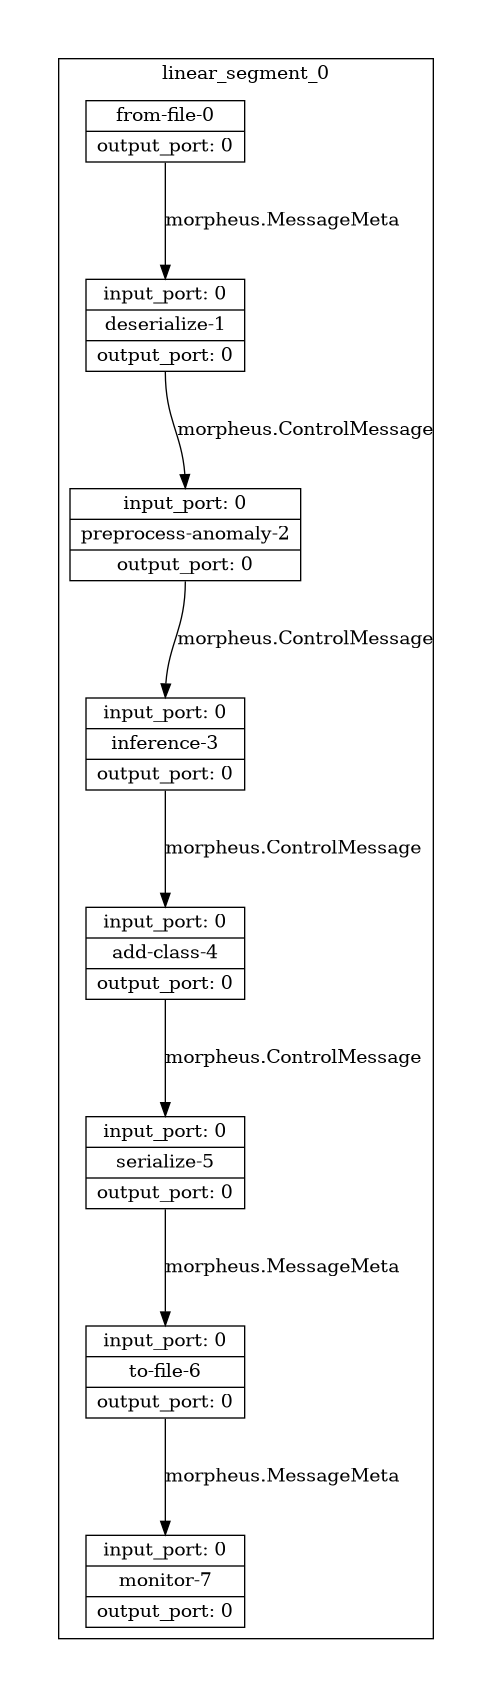

In [17]:
Image(filename=viz_file)

### Run the Morpheus Pipeline ###

In [18]:
await pipeline.run_async()

Pipeline Throughput[Complete]: 5372410 pkts [00:04, 1114440.48 pkts/s]


Let's have a quick look at the output of our pipeline.

In [19]:
!tail -n 3  output/pcap_out.jsonlines | jq

tail: cannot open 'output/pcap_out.jsonlines' for reading: No such file or directory


You will notice that in the tail end of the output result displayed that `probs` is false for the events detected. The `probs:false` field specifically indicates that the analyzed packet is considered normal. This helps network analysts to quickly filter out normal traffic and focus on potential threats or unusual behavior. If the predicted class is `True`, i.e `probs:True`, this signals a potentially significant deviation from normal behavior that might indicate malicious activity, network misconfigurations, or other security concerns that requires further investgation and appropriate actions to mitigate any potential threats.

Now, let's have a look at the Morpheus pipeline we have have constructed.  Calling `pipeline.visualize` allows us to visually see how data flows through the pipeline.

## Quick Reflection on this Use Case ##

In summary we have: 
- Learned how to use built-in and custom Morpheus stages to construct a linear Morpheus pipeline
- Streamed security data from a source (file in this case).
- Performed user defined transformations of the incoming data
- Performed inference using a hosted XGBoost model
- Wrote the outputs to a sink (local disk in this case).
